# Basic Usage Tutorial

This tutorial will walk you through the basic workflow of using Neurodent for rodent EEG analysis.

## Overview

Neurodent provides a streamlined workflow for:
1. Loading EEG recordings from various formats
2. Extracting features from continuous data (Windowed Analysis)
3. Visualizing and analyzing results

Let's get started!

## 1. Installation and Setup

First, ensure you have Neurodent installed. See the [Installation Guide](../installation/index.rst) for detailed instructions.

```bash
pip install neurodent
```

Or with uv:
```bash
uv init yourprojectname
cd yourprojectname
uv add neurodent
```

## 2. Import Required Modules

Let's import the necessary modules from Neurodent:

> **Tip:** To see detailed progress information during processing, check out the [Configuration Guide](configuration.ipynb) to learn how to enable logging.


In [1]:
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from neurodent import (
    LongRecordingOrganizer,
    AnimalOrganizer,
    AnimalAnalyzer,
    WindowAnalysisResult,
    AnimalPlotter,
    ExperimentPlotter,
    set_channel_map,
)
from neurodent.core.utils import get_temp_directory, set_temp_directory

/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_channel_map({
    "LMot": ["C-015", "D-015"],
    "RMot": ["C-016", "D-016"],
    "LBar": ["C-014", "D-014"],
    "RBar": ["C-017", "D-017"],
    "LHip": ["C-012", "D-012"],
    "RHip": ["C-019", "D-019"],
    "LAud": ["C-009", "D-009"],
    "RAud": ["C-022", "D-022"],
    "LVis": ["C-010", "D-010"],
    "RVis": ["C-021", "D-021"],
})

## 3. Configure Temporary Directory (Optional)

Neurodent uses a temporary directory for intermediate files during processing. You can set this to a location with sufficient space:

In [3]:
# Set temporary directory for intermediate files
# set_temp_directory("/path/to/your/temp/dir")

# Or use the default temp directory
print(f"Using temp directory: {get_temp_directory()}")

Using temp directory: /tmp


## 4. Load EEG Data

Neurodent supports multiple data formats through `LongRecordingOrganizer` (LRO):
- **SpikeInterface mode** (`mode="si"`): Load any format supported by SpikeInterface (EDF, NWB, Open Ephys, Neuralynx, binary, etc.). Use `extract_func` for custom readers.
- **MNE mode** (`mode="mne"`): Load any format supported by MNE-Python.
- **Pre-created recording** (`mode=None, recording=...`): Pass an already-loaded SpikeInterface `BaseRecording` directly.

### Loading a single file

The simplest way to load data is to point LRO to a file path.  Here we
load a small EDF recording shipped with the repository:

### Sample recordings

`sample_dataset()` returns the recordings bundled with the package: a 60-second
ColMajor `.bin` + Meta `.csv` pair per animal, and a 5-second `.edf`. Reading `.edf`
needs `pip install neurodent[readers]`.


In [4]:
from neurodent.data import sample_dataset

SAMPLE_DATA = sample_dataset()

### Using your own data

Replace `SAMPLE_DATA` with your own directory and set `extract_func` for your format.
[Data Loading](data_loading.ipynb) covers readers and patterns.


In [5]:
# Load an EDF file by passing a single path
lro = LongRecordingOrganizer(
    item=str(SAMPLE_DATA / "A10" / "A10_recording.edf"),
    mode="si",
    extract_func="read_edf",
    manual_datetimes=datetime(2023, 12, 13),
)

print(f"Sampling frequency: {lro.meta.f_s}")
print(f"Number of channels: {lro.meta.n_channels}")
print(f"Duration: {lro.LongRecording.get_total_duration():.1f} s")

Sampling frequency: 1000.0
Number of channels: 10
Duration: 5.0 s


### Loading multi-file formats with ``DiscoveredFile``

Some formats consist of multiple files per recording (e.g. a `.bin`
data file paired with a `.csv` metadata file).  Wrap these paths in
a `DiscoveredFile` so the LRO treats them as a single unit:

In [6]:
from neurodent.loading import DiscoveredFile

# Two files that together form one recording
discovered = DiscoveredFile(
    paths=(
        str(SAMPLE_DATA / "A10" / "Cage 2 A10-0_ColMajor.bin"),
        str(SAMPLE_DATA / "A10" / "Cage 2 A10-0_Meta.csv"),
    ),
)

lro_bin = LongRecordingOrganizer(
    item=discovered,
    mode="si",
    extract_func="neurodent.readers:read_bin_csv_pair",
    manual_datetimes=datetime(2023, 12, 13),
)

print(f"Sampling frequency: {lro_bin.meta.f_s}")
print(f"Number of channels: {lro_bin.meta.n_channels}")
print(f"Channel names: {lro_bin.meta.channel_names}")

Sampling frequency: 1000.0
Number of channels: 10
Channel names: ['C-009', 'C-010', 'C-012', 'C-014', 'C-015', 'C-016', 'C-017', 'C-019', 'C-021', 'C-022']


## 5. Create Animal Organizer

The `AnimalOrganizer` (AO) uses placeholder patterns (e.g. `{animal}`, `{session}`) to discover and group recordings automatically. For multi-file formats, pass a list of patterns, with one per file type:

In [7]:
# Multi-pattern for paired bin/csv files
ao = AnimalOrganizer(
    pattern=[
        str(SAMPLE_DATA / "{animal}" / "*_ColMajor.bin"),
        str(SAMPLE_DATA / "{animal}" / "*_Meta.csv"),
    ],
    animal_id="A10",
    lro_kwargs={
        "mode": "si",
        "extract_func": "neurodent.readers:read_bin_csv_pair",
        "manual_datetimes": datetime(2023, 12, 13),
    },
)

print(f"Animal Organizer created for {ao.animal_id}")

Animal Organizer created for A10


## 6. Compute Windowed Analysis Results (WAR)

Now we can compute features from the EEG data. Neurodent extracts features in time windows:



In [8]:
# Compute windowed analysis with selected features
# You can specify 'all' or list specific features
features = ['rms', 'psdband', 'cohere', 'psd']

analyzer = AnimalAnalyzer(ao)
analyzer.compute_bad_channels()  # calculate scores for LOF-based filtering

war = analyzer.compute_windowed_analysis(
    features=features,
    multiprocess_mode='serial'  # Options: 'serial', 'dask'
)

print(f"Windowed analysis completed!")
print(f"Features computed: {features}")

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 33.78it/s]


Processing rows:  33%|███▎      | 4/12 [00:00<00:00, 33.74it/s]

Processing rows:  67%|██████▋   | 8/12 [00:00<00:00, 33.97it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 33.84it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 33.78it/s]

Windowed analysis completed!
Features computed: ['rms', 'psdband', 'cohere', 'psd']


## 7. Filter and Clean Data

Neurodent provides filtering methods to remove artifacts and outliers:

In [9]:
# Apply filtering using method chaining
war_filtered = (
    war
    .filter_logrms_range(z_range=3)   # Remove outliers based on log RMS
    .filter_high_rms(max_rms=500)     # Remove high amplitude artifacts
    .filter_low_rms(min_rms=10)       # Remove low amplitude periods
)

print("Filtering completed!")

Filtering completed!


## 8. Basic Visualization

### Single Animal Plots

Use `AnimalPlotter` to visualize data over time from a single animal.

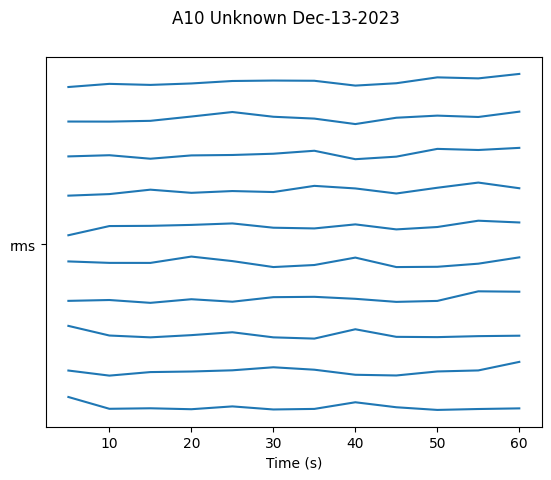

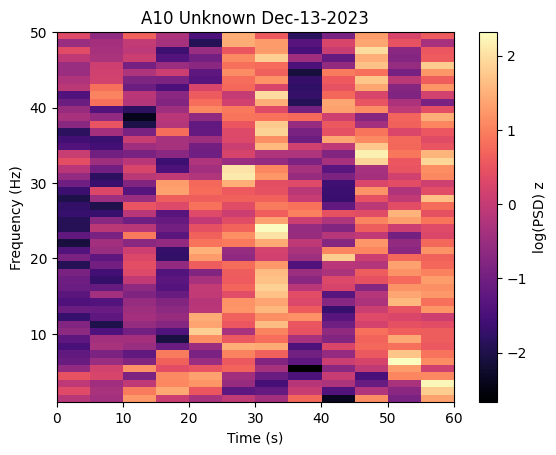

In [10]:
# Create plotter for single animal.
# AnimalPlotter methods draw and display the figure themselves and return None,
# so there is nothing to assign and no need to call plt.show().
ap = AnimalPlotter(war_filtered)

# Plot RMS over time
ap.plot_linear_temporal(features=['rms'])

# Plot the power spectrogram
ap.plot_psd_spectrogram()

## 9. Aggregate Time Windows (Optional)

Average windows within each session and light/dark phase, which is the default `groupby=['animalday', 'isday']`. This saves memory and summarises a session.

> **Note:** You should not aggregate before plotting time-series data with `AnimalPlotter`, as this removes the temporal information needed for over-time visualizations.

In [11]:
# Example: Aggregate for summary statistics
war_aggregated = war_filtered.copy()
war_aggregated.aggregate_time_windows()

/home/runner/work/neurodent/neurodent/src/neurodent/results/window_analysis_result.py:561: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated_df = result_grouped.apply(


### Multi-Animal Comparison

To compare across multiple animals, use `ExperimentPlotter`.  Here we
build a second WAR for animal F22 so we can compare the two:

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 34.08it/s]


Processing rows:  33%|███▎      | 4/12 [00:00<00:00, 34.21it/s]

Processing rows:  67%|██████▋   | 8/12 [00:00<00:00, 34.63it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 34.04it/s]

Processing rows: 100%|██████████| 12/12 [00:00<00:00, 34.08it/s]

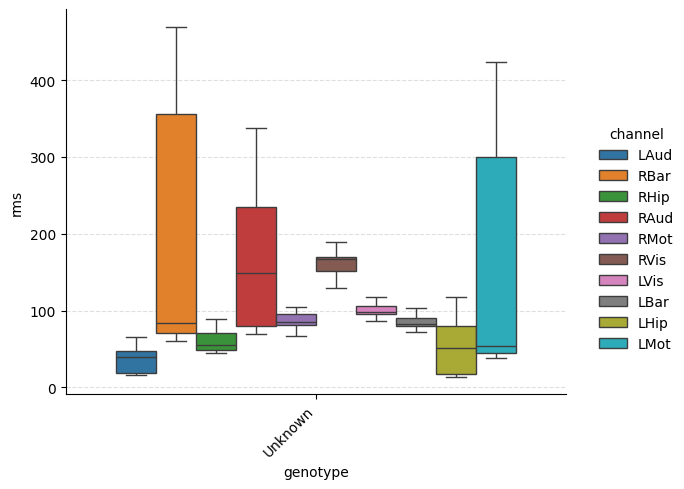

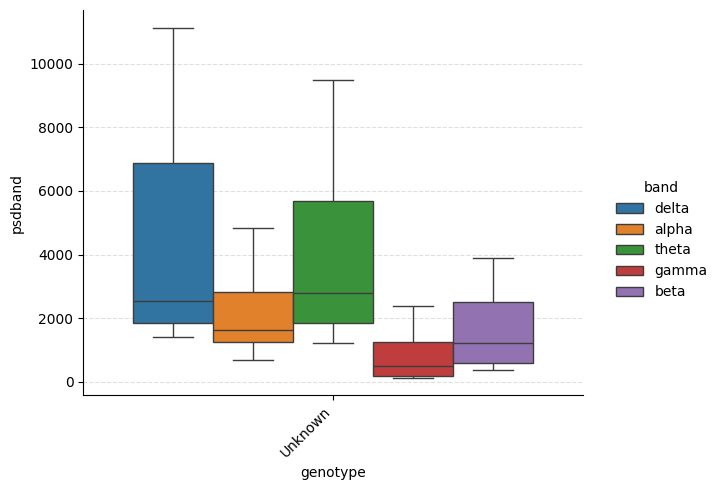

In [12]:
# Build a WAR for a second animal (F22)
ao_f22 = AnimalOrganizer(
    pattern=[
        str(SAMPLE_DATA / "{animal}" / "*_ColMajor.bin"),
        str(SAMPLE_DATA / "{animal}" / "*_Meta.csv"),
    ],
    animal_id="F22",
    lro_kwargs={
        "mode": "si",
        "extract_func": "neurodent.readers:read_bin_csv_pair",
        "manual_datetimes": datetime(2023, 12, 12),
    },
)

analyzer_f22 = AnimalAnalyzer(ao_f22)
analyzer_f22.compute_bad_channels()

war_f22 = analyzer_f22.compute_windowed_analysis(
    features=features, multiprocess_mode="serial"
)
war_f22_filtered = (
    war_f22
    .filter_logrms_range(z_range=3)
    .filter_high_rms(max_rms=500)
    .filter_low_rms(min_rms=10)
)

# Create ExperimentPlotter with both animals
wars = [war_filtered, war_f22_filtered]

ep = ExperimentPlotter(
    wars,
    features=features,
    plot_order={'genotype': ['Unknown']},  # genotype is set via samples config; 'Unknown' is the default
)

# Categorical plot grouped by genotype
ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    catplot_params={'showfliers': False},
)
plt.show()

# PSD band powers grouped by genotype
ep.plot_catplot(
    'psdband',
    groupby='genotype',
    x='genotype',
    hue='band',
    kind='box',
    collapse_channels=True,
    catplot_params={'showfliers': False},
)
plt.show()

## 10. Save Results

You can save your WAR objects for later analysis:

In [13]:
import tempfile

# Use a temporary directory for demonstration purposes
with tempfile.TemporaryDirectory() as tmpdir:
    output_path = Path(tmpdir) / "A10"
    output_path.mkdir(parents=True, exist_ok=True)

    # Save WAR as parquet + json
    war_filtered.save_parquet_and_json(folder=output_path)
    print(f"WAR saved to {output_path}")

    # Load WAR
    war_loaded = WindowAnalysisResult.load_parquet_and_json(output_path)
    print(f"Loaded result for {war_loaded.animal_id}")

WAR saved to /tmp/tmpktyzsgzf/A10
Loaded result for A10


## Next Steps

- **[Data Loading Tutorial](data_loading.ipynb)**: Learn about loading different data formats
- **[Windowed Analysis Tutorial](../tutorials/windowed_analysis.ipynb)**: Deep dive into feature extraction
- **[Visualization Tutorial](../tutorials/visualization.ipynb)**: Advanced plotting techniques
- **[Spike Analysis Tutorial](../tutorials/spike_analysis.ipynb)**: Frequency-domain spike detection